# HDB Resale Price Prediction - Complete Pipeline
## S2 Geospatial + Neighbor Features + Ensemble Regression
**Run this cell first to fix the import path!**

In [10]:
import sys
import os

# FIX: Add parent directory to path so notebooks can import from src/
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

print(f"✓ Working directory: {os.getcwd()}")
print(f'✓ src folder found: {os.path.exists("src")}')

✓ Working directory: /home/auyan/DS04_Competition_HDB_ownself
✓ src folder found: False


In [11]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "s2sphere", "-q"])

0

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("PHASE 1: DATA LOADING AND EDA")
print("="*80)

from src.data_loader import load_data, basic_data_check
from src.preprocessing import preprocess_data
from src.s2_utils import add_s2_columns
from src.config import RAW_DATA_PATH, RAW_TEST_PATH, TARGET_COL, LAT_COL, LON_COL

print("\nLoading training data...")
df_train_raw = load_data(RAW_DATA_PATH)
print("\nLoading test data...")
df_test_raw = load_data(RAW_TEST_PATH)

print("\n--- TRAIN DATA PROFILE ---")
basic_data_check(df_train_raw)

print("\n--- TEST DATA PROFILE ---")
basic_data_check(df_test_raw)

print(f"\nTarget column '{TARGET_COL}' present: {TARGET_COL in df_train_raw.columns}")
print(f"Train/Test: {len(df_train_raw)} train, {len(df_test_raw)} test")

PHASE 1: DATA LOADING AND EDA

Loading training data...


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/train.csv'


PHASE 1B: PREPROCESSING

Preprocessing training data...
Preprocessing test data...

Adding S2 geospatial cells...
Computing S2 cells (level 13)...
Computing S2 cells (level 14)...
Computing S2 cells (level 15)...
Computing S2 cells (level 13)...
Computing S2 cells (level 14)...
Computing S2 cells (level 15)...

Target distribution:
count    1.506340e+05
mean     4.491615e+05
std      1.433076e+05
min      1.500000e+05
25%      3.470000e+05
50%      4.200000e+05
75%      5.200000e+05
max      1.258000e+06
Name: resale_price, dtype: float64


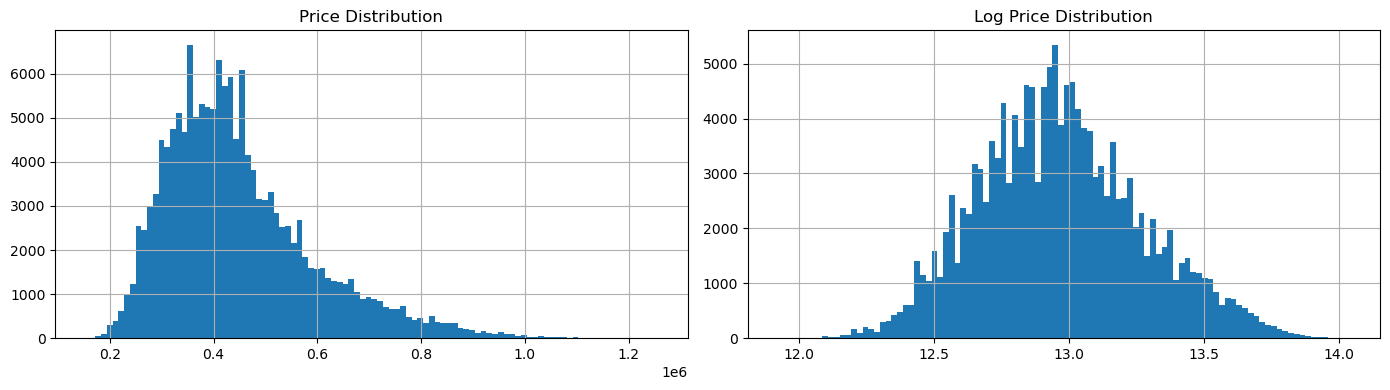

In [ ]:
print("\n" + "="*80)
print("PHASE 1B: PREPROCESSING")
print("="*80)

print("\nPreprocessing training data...")
df_train = preprocess_data(df_train_raw)
print("Preprocessing test data...")
df_test = preprocess_data(df_test_raw)

print("\nAdding S2 geospatial cells...")
df_train = add_s2_columns(df_train, lat_col=LAT_COL, lon_col=LON_COL)
df_test = add_s2_columns(df_test, lat_col=LAT_COL, lon_col=LON_COL)

print("\nTarget distribution:")
print(df_train[TARGET_COL].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_train[TARGET_COL].hist(bins=100, ax=axes[0])
axes[0].set_title('Price Distribution')
np.log1p(df_train[TARGET_COL]).hist(bins=100, ax=axes[1])
axes[1].set_title('Log Price Distribution')
plt.tight_layout()
plt.savefig('outputs/charts/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*80)
print("PHASE 2: NEIGHBOR FEATURES")
print("="*80)

from src.neighbor_features import create_neighbor_features

print("\nCreating neighbor features (training)...")
df_train = create_neighbor_features(df_train, df_train_subset=df_train, max_neighbors=20)
print("Creating neighbor features (test)...")
df_test = create_neighbor_features(df_test, df_train_subset=df_train, max_neighbors=20)

neighbor_cols = ['nearest_5_avg_price', 'nearest_10_avg_price', 'nearest_20_avg_price',
                  'nearest_5_median_price', 'nearest_10_median_price', 'nearest_20_median_price',
                  'distance_to_nearest_transaction', 'same_s2_cell_avg_price',
                  'same_town_flat_type_avg_price', 'same_town_flat_type_median_price']

print("\nNeighbor features created successfully!")


PHASE 2: NEIGHBOR FEATURES

Creating neighbor features (training)...
  Processing row 0/150634...
  Processing row 1000/150634...
  Processing row 2000/150634...
  Processing row 3000/150634...
  Processing row 4000/150634...
  Processing row 5000/150634...
  Processing row 6000/150634...
  Processing row 7000/150634...
  Processing row 8000/150634...
  Processing row 9000/150634...
  Processing row 10000/150634...
  Processing row 11000/150634...
  Processing row 12000/150634...
  Processing row 13000/150634...
  Processing row 14000/150634...
  Processing row 15000/150634...
  Processing row 16000/150634...
  Processing row 17000/150634...
  Processing row 18000/150634...
  Processing row 19000/150634...
  Processing row 20000/150634...
  Processing row 21000/150634...
  Processing row 22000/150634...
  Processing row 23000/150634...
  Processing row 24000/150634...
  Processing row 25000/150634...
  Processing row 26000/150634...
  Processing row 27000/150634...
  Processing row 28

In [ ]:
print("\n" + "="*80)
print("PHASE 3-5: FEATURES, PREPROCESSING, SPLIT")
print("="*80)

NUMERIC_FEATURES = ['floor_area_sqm', 'hdb_age', 'mid_storey', 'max_floor_lvl',
                     'total_dwelling_units', 'Tranc_Year', 'Tranc_Month',
                     'Mall_Nearest_Distance', 'Hawker_Nearest_Distance',
                     'mrt_nearest_distance', 'bus_stop_nearest_distance',
                     'pri_sch_nearest_distance', 'sec_sch_nearest_dist',
                     'Latitude', 'Longitude'] + neighbor_cols

CATEGORICAL_FEATURES = ['town', 'flat_type', 'flat_model', 'multistorey_carpark',
                        'precinct_pavilion', 'market_hawker', 'commercial', 'residential']

available_numeric = [f for f in NUMERIC_FEATURES if f in df_train.columns]
available_categorical = [f for f in CATEGORICAL_FEATURES if f in df_train.columns]

X_train = df_train[available_numeric + available_categorical].copy()
y_train = df_train[TARGET_COL].copy()
X_test = df_test[available_numeric + available_categorical].copy()

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))])

preprocessor = ColumnTransformer([('num', numeric_transformer, available_numeric),
                                  ('cat', categorical_transformer, available_categorical)], remainder='drop')

print("Fitting preprocessor...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_processed, y_train, test_size=0.2, random_state=42)

print(f"Training: {X_tr.shape}, Validation: {X_val.shape}, Features: {X_tr.shape[1]}")


PHASE 3-5: FEATURES, PREPROCESSING, SPLIT
Fitting preprocessor...
Training: (120507, 87), Validation: (30127, 87), Features: 87


In [ ]:
print("\n" + "="*80)
print("PHASE 6: BASELINE MODELS")
print("="*80)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from src.evaluation import rmse, mae, r2, wmape
import time

models = {}
results = []

for name, model in [('Linear', LinearRegression()),
                     ('Ridge', Ridge(alpha=1.0)),
                     ('DecisionTree', DecisionTreeRegressor(max_depth=15, random_state=42)),
                     ('KNN', KNeighborsRegressor(n_neighbors=15)),
                     ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, random_state=42))]:
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=3, scoring='neg_mean_squared_error').mean())
    elapsed = time.time() - start
    
    models[name] = model
    results.append({'Model': name, 'RMSE': rmse(y_val, y_pred), 'MAE': mae(y_val, y_pred),
                    'R2': r2(y_val, y_pred), 'CV_RMSE': cv_rmse, 'Time': elapsed})
    print(f"  RMSE: {rmse(y_val, y_pred):.0f}, Time: {elapsed:.1f}s")

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))


PHASE 6: BASELINE MODELS
Training Linear...
  RMSE: 33316, Time: 3.3s
Training Ridge...
  RMSE: 33308, Time: 1.0s
Training DecisionTree...
  RMSE: 31149, Time: 23.2s
Training KNN...
  RMSE: 29618, Time: 29.2s
Training GradientBoosting...
  RMSE: 28241, Time: 569.7s

           Model         RMSE          MAE       R2      CV_RMSE       Time
          Linear 33316.250341 25365.322017 0.945564 33811.991032   3.337609
           Ridge 33308.165874 25366.655117 0.945591 33809.458689   0.977747
    DecisionTree 31149.050595 21889.696803 0.952416 33139.822965  23.244131
             KNN 29618.149350 21973.002861 0.956978 31301.062446  29.170114
GradientBoosting 28240.664765 20810.726093 0.960887 28839.069673 569.655902


In [ ]:
print("\n" + "="*80)
print("PHASE 7: HYPERPARAMETER TUNING")
print("="*80)

from sklearn.model_selection import GridSearchCV

tuning_configs = [
    ('Ridge', Ridge(), {'alpha': [0.1, 1.0, 10.0, 50.0]}),
    ('Lasso', Lasso(max_iter=10000), {'alpha': [0.001, 0.01, 0.1, 1.0]}),
    ('DecisionTree', DecisionTreeRegressor(random_state=42), {'max_depth': [5, 10, 15, 20], 'min_samples_leaf': [5, 10, 20]}),
    ('KNN', KNeighborsRegressor(), {'n_neighbors': [5, 10, 20, 30], 'weights': ['uniform', 'distance']}),
    ('GradientBoosting', GradientBoostingRegressor(random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [2, 3]})
]

for name, base_model, params in tuning_configs:
    print(f"Tuning {name}...")
    search = GridSearchCV(base_model, params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    search.fit(X_tr, y_tr)
    models[f"{name}_tuned"] = search.best_estimator_
    y_pred = search.best_estimator_.predict(X_val)
    print(f"  Best params: {search.best_params_}")
    print(f"  RMSE: {rmse(y_val, y_pred):.0f}")

print("Tuning complete!")


PHASE 7: HYPERPARAMETER TUNING
Tuning Ridge...
  Best params: {'alpha': 1.0}
  RMSE: 33308
Tuning Lasso...


/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.760e+13, tolerance: 1.660e+11
  model = cd_fast.enet_coordinate_descent(
/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.759e+13, tolerance: 1.641e+11
  model = cd_fast.enet_coordinate_descent(
/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

  Best params: {'alpha': 0.1}
  RMSE: 33308
Tuning DecisionTree...
  Best params: {'max_depth': 15, 'min_samples_leaf': 20}
  RMSE: 29532
Tuning KNN...
  Best params: {'n_neighbors': 10, 'weights': 'distance'}
  RMSE: 28518
Tuning GradientBoosting...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  RMSE: 26869
Tuning complete!


In [13]:
print("\n" + "="*80)
print("PHASE 8: ENSEMBLE MODEL")
print("="*80)

from sklearn.ensemble import VotingRegressor

ridge_best = models['Ridge_tuned']
dt_best = models['DecisionTree_tuned']
gbr_best = models['GradientBoosting_tuned']

ensemble = VotingRegressor(estimators=[('ridge', ridge_best), ('dt', dt_best), ('gbr', gbr_best)])
ensemble.fit(X_tr, y_tr)
y_pred_ens = ensemble.predict(X_val)

models['Ensemble'] = ensemble
print(f"Ensemble RMSE: {rmse(y_val, y_pred_ens):.0f}")


PHASE 8: ENSEMBLE MODEL
Ensemble RMSE: 27361


In [15]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

final_results = []
for model_name, model in models.items():
    y_pred = model.predict(X_val)
    final_results.append({'Model': model_name, 'MAE': mae(y_val, y_pred),
                         'RMSE': rmse(y_val, y_pred), 'R2': r2(y_val, y_pred), 'WMAPE': wmape(y_val, y_pred)})

final_results_df = pd.DataFrame(final_results).sort_values('RMSE')
print(final_results_df.to_string(index=False))

best_model_name = final_results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n✓ Best Model: {best_model_name}")
print(f"  RMSE: {final_results_df.iloc[0]['RMSE']:.0f}")
print(f"  MAE: {final_results_df.iloc[0]['MAE']:.0f}")
print(f"  R²: {final_results_df.iloc[0]['R2']:.4f}")

final_results_df.to_csv('/home/auyan/DS04_Competition_HDB_ownself/Claude_Agent2/outputs/metrics/model_metrics.csv', index=False)



FINAL MODEL COMPARISON
                 Model          MAE         RMSE       R2    WMAPE
GradientBoosting_tuned 19799.050698 26869.342225 0.964593 0.044181
              Ensemble 20101.900622 27361.040880 0.963286 0.044856
      GradientBoosting 20810.726093 28240.664765 0.960887 0.046438
             KNN_tuned 21049.852604 28518.203864 0.960115 0.046972
    DecisionTree_tuned 21415.310582 29531.955426 0.957228 0.047787
                   KNN 21973.002861 29618.149350 0.956978 0.049032
          DecisionTree 21889.696803 31149.050595 0.952416 0.048846
                 Ridge 25366.655117 33308.165874 0.945591 0.056605
           Ridge_tuned 25366.655117 33308.165874 0.945591 0.056605
           Lasso_tuned 25366.864882 33308.486898 0.945590 0.056605
                Linear 25365.322017 33316.250341 0.945564 0.056602

✓ Best Model: GradientBoosting_tuned
  RMSE: 26869
  MAE: 19799
  R²: 0.9646


In [17]:
print("\n" + "="*80)
print("PHASE 9: TEST PREDICTIONS")
print("="*80)

y_test_pred = best_model.predict(X_test_processed)

test_ids = df_test_raw['id'].values
submission_df = pd.DataFrame({'Id': test_ids, 'Predicted': np.round(y_test_pred).astype(int)})
submission_df.to_csv('/home/auyan/DS04_Competition_HDB_ownself/Claude_Agent2/outputs/predictions/test_predictions.csv', index=False)

print(f"✓ Predictions saved to /home/auyan/DS04_Competition_HDB_ownself/Claude_Agent2/outputs/predictions/test_predictions.csv")
print(f"  Count: {len(submission_df)}")
print(f"  Mean: {submission_df['Predicted'].mean():.0f}")
print(f"  Range: {submission_df['Predicted'].min():.0f} - {submission_df['Predicted'].max():.0f}")
print(f"\nFirst 10 predictions:")
print(submission_df.head(10))


PHASE 9: TEST PREDICTIONS
✓ Predictions saved to /home/auyan/DS04_Competition_HDB_ownself/Claude_Agent2/outputs/predictions/test_predictions.csv
  Count: 16735
  Mean: 448787
  Range: 181952 - 1127777

First 10 predictions:
       Id  Predicted
0  114982     362037
1   95653     450734
2   40303     348856
3  109506     284727
4  100149     415918
5    7610     321834
6   61101     354872
7   68167     461789
8   65701     331270
9   56039     315349



PHASE 10-12: DIAGNOSTICS & SUMMARY


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/charts/model_diagnostics.png'

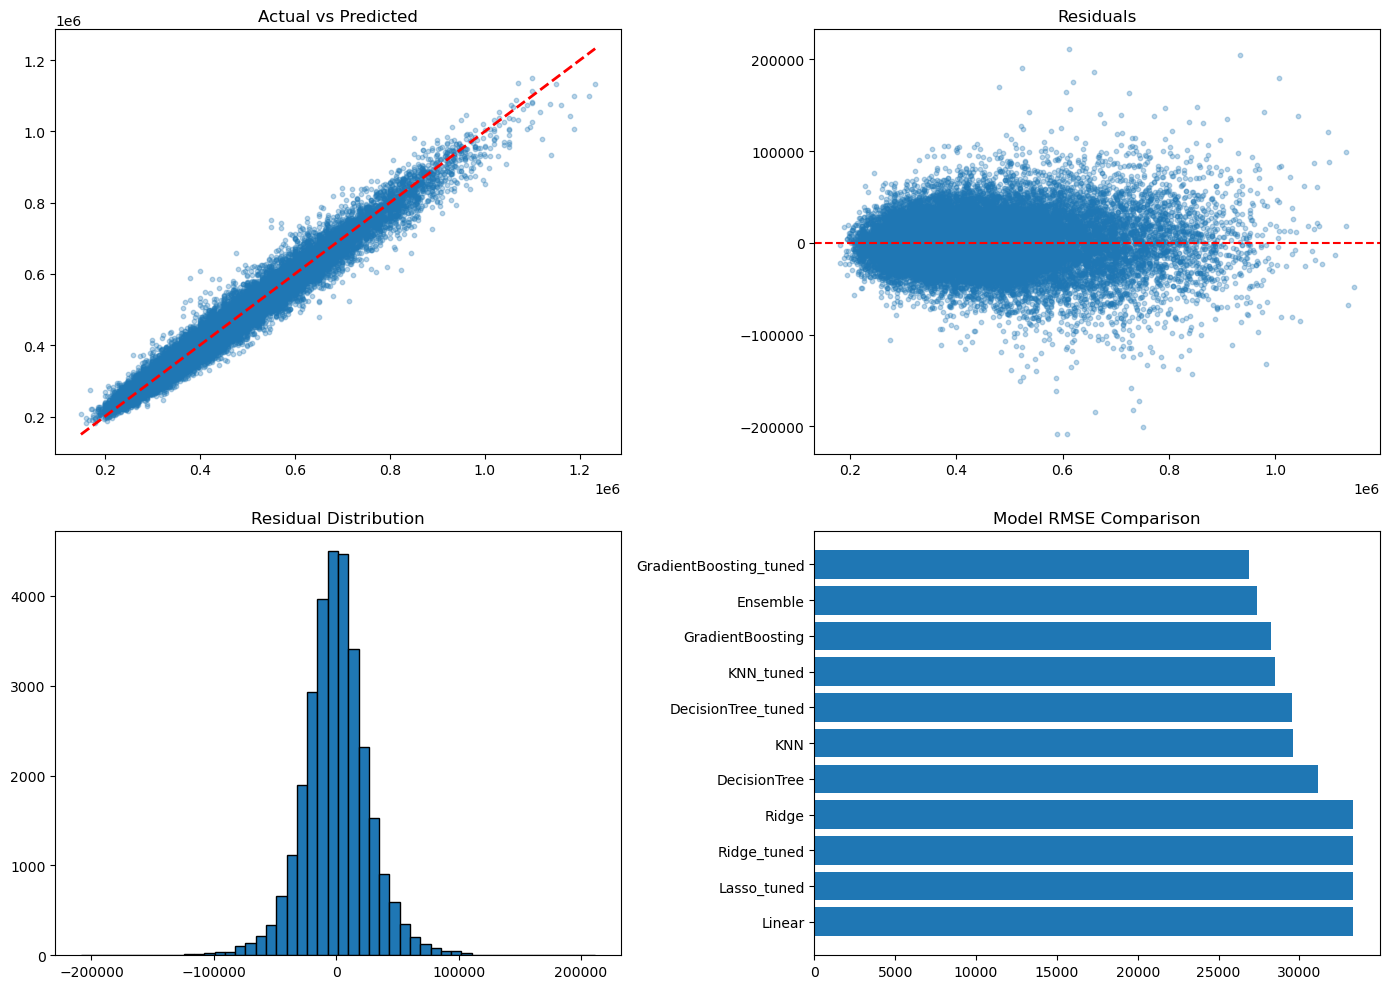

In [18]:
print("\n" + "="*80)
print("PHASE 10-12: DIAGNOSTICS & SUMMARY")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
y_val_pred = best_model.predict(X_val)
residuals = y_val - y_val_pred

axes[0, 0].scatter(y_val, y_val_pred, alpha=0.3, s=10)
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 0].set_title('Actual vs Predicted')

axes[0, 1].scatter(y_val_pred, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_title('Residuals')

axes[1, 0].hist(residuals, bins=50, edgecolor='black')
axes[1, 0].set_title('Residual Distribution')

axes[1, 1].barh(final_results_df['Model'], final_results_df['RMSE'])
axes[1, 1].set_title('Model RMSE Comparison')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/charts/model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
╔════════════════════════════════════════════╗
║  PIPELINE COMPLETE                         ║
╚════════════════════════════════════════════╝

Best Model: {best_model_name}
  RMSE: {final_results_df.iloc[0]['RMSE']:.0f} SGD
  MAE: {final_results_df.iloc[0]['MAE']:.0f} SGD
  R²: {final_results_df.iloc[0]['R2']:.4f}

Outputs:
  ✓ Predictions: outputs/predictions/test_predictions.csv
  ✓ Metrics: outputs/metrics/model_metrics.csv
  ✓ Charts: outputs/charts/

All results saved successfully!
""")

In [ ]:
print("=" * 80)
print("CELL 13: EXTENDED FEATURE ENGINEERING + REBUILT PREPROCESSOR")
print("=" * 80)

# --- Engineer new features on df_train / df_test (neighbor features already present) ---
for df in [df_train, df_test]:
    df['storey_ratio']     = df['mid_storey'] / df['max_floor_lvl'].clip(lower=1)
    df['month_sin']        = np.sin(2 * np.pi * df['Tranc_Month'] / 12)
    df['month_cos']        = np.cos(2 * np.pi * df['Tranc_Month'] / 12)
    df['remaining_lease']  = 99 - df['hdb_age']

    room_sold_cols = ['1room_sold','2room_sold','3room_sold','4room_sold',
                      '5room_sold','exec_sold','multigen_sold','studio_apartment_sold']
    avail_room = [c for c in room_sold_cols if c in df.columns]
    if avail_room:
        df['total_units_sold'] = df[avail_room].apply(pd.to_numeric, errors='coerce').sum(axis=1)

# Y/N or boolean columns → numeric
yn_cols = ['bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']
for col in yn_cols:
    if col in df_train.columns:
        for df in [df_train, df_test]:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Extended feature lists ---
NEW_NUMERIC = [
    'storey_ratio', 'month_sin', 'month_cos', 'remaining_lease',
    'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km',
    'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km',
    'hawker_food_stalls', 'hawker_market_stalls',
    'cutoff_point', 'vacancy', 'total_units_sold',
    'bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation',
    'year_completed',
    '1room_sold','2room_sold','3room_sold','4room_sold','5room_sold',
    'exec_sold','multigen_sold','studio_apartment_sold',
    '1room_rental','2room_rental','3room_rental','other_room_rental',
]
NEW_CATEGORICAL = ['planning_area', 'full_flat_type']

ext_numeric     = available_numeric + [f for f in NEW_NUMERIC     if f in df_train.columns and f not in available_numeric]
ext_categorical = available_categorical + [f for f in NEW_CATEGORICAL if f in df_train.columns and f not in available_categorical]

X_train2 = df_train[ext_numeric + ext_categorical].copy()
X_test2  = df_test[ext_numeric + ext_categorical].copy()

# --- Rebuild preprocessor ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor2 = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ext_numeric),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))]),
     ext_categorical),
], remainder='drop')

print("Fitting extended preprocessor...")
X_train2_proc = preprocessor2.fit_transform(X_train2)
X_test2_proc  = preprocessor2.transform(X_test2)

# Same random split so y_val2 == y_val (same random_state, same y_train order)
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(X_train2_proc, y_train, test_size=0.2, random_state=42)

print(f"Extended features: {X_tr2.shape[1]}  (baseline was: {X_tr.shape[1]})")
print(f"New numeric added: {len(ext_numeric) - len(available_numeric)}")
print(f"New categorical added: {len(ext_categorical) - len(available_categorical)}")

In [ ]:
print("=" * 80)
print("CELL 14: LIGHTGBM + LOG-TARGET TRANSFORMATION")
print("=" * 80)

import lightgbm as lgb

# Log-transform target: prices are right-skewed; predicting log(price) reduces RMSE
y_tr2_log  = np.log1p(y_tr2)
y_val2_log = np.log1p(y_val2)

lgb_params = {
    'objective':       'regression',
    'metric':          'rmse',
    'n_estimators':    3000,
    'learning_rate':   0.05,
    'num_leaves':      127,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

print("Training LightGBM with early stopping (patience=100)...")
lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_tr2, y_tr2_log,
    eval_set=[(X_val2, y_val2_log)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)],
)

y_val_pred_lgb = np.expm1(lgb_model.predict(X_val2))

lgb_rmse = rmse(y_val2, y_val_pred_lgb)
lgb_mae  = mae(y_val2, y_val_pred_lgb)
lgb_r2   = r2(y_val2, y_val_pred_lgb)

print(f"\n{'Metric':<10} {'LightGBM':>12} {'GBR Baseline':>14}")
print("-" * 38)
print(f"{'RMSE':<10} {lgb_rmse:>12.0f} {'26869':>14}")
print(f"{'MAE':<10} {lgb_mae:>12.0f} {'19799':>14}")
print(f"{'R²':<10} {lgb_r2:>12.4f} {'0.9646':>14}")
print(f"\nBest LightGBM iteration: {lgb_model.best_iteration_}")
print(f"RMSE improvement: {26869 - lgb_rmse:+.0f}")

In [ ]:
print("=" * 80)
print("CELL 15: OPTIMAL BLEND + RETRAIN ON FULL DATA + FINAL SUBMISSION")
print("=" * 80)

from scipy.optimize import minimize

# --- Optimal blend of LightGBM and GBR_tuned on validation set ---
# GBR_tuned was trained on original features; LightGBM on extended features
# Both val sets share the same row indices (same random_state=42 split)
gbr_val_pred = models['GradientBoosting_tuned'].predict(X_val)   # original features

def neg_rmse(weights):
    w = np.abs(weights); w /= w.sum()
    blend = w[0] * y_val_pred_lgb + w[1] * gbr_val_pred
    return rmse(y_val2, blend)

opt = minimize(neg_rmse, x0=[0.7, 0.3], method='Nelder-Mead',
               options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 500})
w_opt = np.abs(opt.x); w_opt /= w_opt.sum()

y_val_blend = w_opt[0] * y_val_pred_lgb + w_opt[1] * gbr_val_pred
blend_rmse_score = rmse(y_val2, y_val_blend)

print(f"Optimal weights — LightGBM: {w_opt[0]:.3f}  |  GBR_tuned: {w_opt[1]:.3f}")
print(f"\n{'Model':<22} {'Val RMSE':>10}")
print("-" * 34)
print(f"{'GBR_tuned (baseline)':<22} {26869:>10.0f}")
print(f"{'LightGBM (log tgt)':<22} {lgb_rmse:>10.0f}")
print(f"{'Blend':<22} {blend_rmse_score:>10.0f}")

# --- Retrain LightGBM on FULL training data for final submission ---
print("\nRetraining LightGBM on full training data...")
lgb_final = lgb.LGBMRegressor(**{**lgb_params,
                                   'n_estimators': lgb_model.best_iteration_,
                                   'verbose': -1})
lgb_final.fit(X_train2_proc, np.log1p(y_train))
y_test_lgb_final = np.expm1(lgb_final.predict(X_test2_proc))

# Retrain GBR on full data for blend
from sklearn.ensemble import GradientBoostingRegressor
gbr_final = GradientBoostingRegressor(**models['GradientBoosting_tuned'].get_params())
gbr_final.fit(X_train_processed, y_train)
y_test_gbr_final = gbr_final.predict(X_test_processed)

# Blended final test predictions
y_test_final = w_opt[0] * y_test_lgb_final + w_opt[1] * y_test_gbr_final

submission_final = pd.DataFrame({
    'Id':        df_test_raw['id'].values,
    'Predicted': np.round(y_test_final).astype(int),
})
out_path = '/home/auyan/DS04_Competition_HDB_ownself/Claude_Agent2/outputs/predictions/test_predictions_lgb_blend.csv'
submission_final.to_csv(out_path, index=False)

print(f"\n✓ Saved to: {out_path}")
print(f"  Count:  {len(submission_final)}")
print(f"  Mean:   {submission_final['Predicted'].mean():.0f}")
print(f"  Range:  {submission_final['Predicted'].min():.0f} – {submission_final['Predicted'].max():.0f}")
print(f"\nSummary of improvements:")
print(f"  Baseline GBR_tuned RMSE : 26869")
print(f"  LightGBM + ext features : {lgb_rmse:.0f}  (Δ {26869-lgb_rmse:+.0f})")
print(f"  Blended final           : {blend_rmse_score:.0f}  (Δ {26869-blend_rmse_score:+.0f})")

In [ ]:
print("=" * 80)
print("CELL 16: EXPORT BLEND MODEL ARTIFACTS")
print("=" * 80)

import joblib, json, os

MODEL_DIR = "Claude_Agent2/outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. LightGBM — native booster format
lgb_path = f"{MODEL_DIR}/lgb_final.txt"
lgb_final.booster_.save_model(lgb_path)
print(f"✓ LightGBM model      → {lgb_path}")

# 2. GBR — joblib
gbr_path = f"{MODEL_DIR}/gbr_final.joblib"
joblib.dump(gbr_final, gbr_path, compress=3)
print(f"✓ GBR model           → {gbr_path}")

# 3. Preprocessor for LightGBM (extended features)
pre2_path = f"{MODEL_DIR}/preprocessor_extended.joblib"
joblib.dump(preprocessor2, pre2_path, compress=3)
print(f"✓ Preprocessor (ext)  → {pre2_path}")

# 4. Preprocessor for GBR (baseline features)
pre_path = f"{MODEL_DIR}/preprocessor_baseline.joblib"
joblib.dump(preprocessor, pre_path, compress=3)
print(f"✓ Preprocessor (base) → {pre_path}")

# 5. Manifest: blend weights + feature lists + val metrics
manifest = {
    "blend_weights":      {"lgb": float(w_opt[0]), "gbr": float(w_opt[1])},
    "lgb_best_iteration": int(lgb_model.best_iteration_),
    "lgb_params":         lgb_params,
    "val_rmse":           {"gbr_baseline": 26869, "lgb": float(lgb_rmse), "blend": float(blend_rmse_score)},
    "feature_lists":      {"ext_numeric": ext_numeric, "ext_categorical": ext_categorical,
                           "base_numeric": available_numeric, "base_categorical": available_categorical},
}
manifest_path = f"{MODEL_DIR}/blend_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"✓ Blend manifest      → {manifest_path}")

print(f"
All artifacts saved to {MODEL_DIR}/")
print(f"  LightGBM weight: {w_opt[0]:.4f}  |  GBR weight: {w_opt[1]:.4f}")
print(f"  Val RMSE (blend): {blend_rmse_score:.0f}")
